Another way to multiply

In [8]:
import numpy as np

# Matrices as matrix objects
c = np.matrix([[1, 2], [3, 4]])
d = np.matrix([[5, 6, 7], [8, 9, 10]])
print("\nc", type(c))
print(c)
print("\nd", type(d))
print(d)
print("\ndot product of two matrix objects")
print(np.dot(c, d))



c <class 'numpy.matrix'>
[[1 2]
 [3 4]]

d <class 'numpy.matrix'>
[[ 5  6  7]
 [ 8  9 10]]

dot product of two matrix objects
[[21 24 27]
 [47 54 61]]


Converting matrix and array objects in numpy

In [9]:
import numpy as np
from sympy import *

# Create an array
arr = np.array([[14, 0, 11, 3], [22, 25, 4, 7], [-12, -34, -3, -4]])

# Create a matrix from that array
M = Matrix(arr)
print("Matrix : {} ".format(M))

# could start by creating a matrix instead
# M = Matrix([[14, 0, 11, 3], [22, 23, 4, 7], [-12, -34, -3, -4]])

# convert that matrix back to an array
A = np.array(M)
print("\n same matrix:")
print(A)

# Solve using rref in the matrix
print("\n answers:")
M_rref = M.rref()
x = M_rref[0][3]
y = M_rref[0][7]
z = M_rref[0][11]
print("x = ", x)
print("y = ", y)
print("z = ", z)

print("\n row echelon form of matrix M: \n {}".format(M_rref))


Matrix : Matrix([[14, 0, 11, 3], [22, 25, 4, 7], [-12, -34, -3, -4]]) 

 same matrix:
[[14 0 11 3]
 [22 25 4 7]
 [-12 -34 -3 -4]]

 answers:
x =  445/1358
y =  10/679
z =  -14/97

 row echelon form of matrix M: 
 (Matrix([
[1, 0, 0, 445/1358],
[0, 1, 0,   10/679],
[0, 0, 1,   -14/97]]), (0, 1, 2))


# A quadratic equation from 3 points

points: (x1, y1), (x2, y2), (x3, y3)<p>
Standard equation: Ax<sup>2</sup> + Bx + C = y<br>
first point: A(x1)<sup>2</sup> + B(x1) + C = y1<br>
Second point: A(x2)<sup>2</sup> + B(x2) + C = y2<br>
Third point: A(x3)<sup>2</sup> + B(x3) + C = y3<p>
Matrix:<br>
$\begin{bmatrix} (x1)^2 & x1 & 1 & y1
\\ (x2)^2 & x2 & 1 & y2
\\ (x3)^2 & x3 & 1 & y3  \end{bmatrix}$

In [ ]:
import numpy as np
from sympy import *

# points
x1=-2
y1=0
x2=-3
y2=0
x3=-2.5
y3=-.25


M = Matrix([[x1**2,x1,1,y1],[x2**2,x2,1,y2],[x3**2,x3,1,y3]])
m_rref = M.rref()

# answers
a = round(m_rref[0][3])
b = round(m_rref[0][7])
c = round(m_rref[0][11])
print("a = ", a)
print("b = ", b)
print("c = ", c)

print("y = ", a,"x**2 + ", b, "x + ", c)
print("\n row echelon form of matrix M: \n {}".format(m_rref))



# Inverse matrix to solve a system of equations

In [ ]:
import numpy as np
from sympy import *

# use arrays instead of matrices
a1 = np.array([[14, 0, 11], [22, 23, 4], [-12, -34, -3]])
a2 = np.array([[3],[7],[-4]])

m_inv = np.linalg.inv(a1)
m_dot_a = np.around(np.dot(m_inv,a1))
m_dot = np.dot(m_inv,a2)
print(m_dot)

print("\n compare:")
print(445/1358)
print(10/679)
print(-14/97)

print(m_dot_a)


Another inverse matrix example

In [ ]:
import numpy as np
from sympy import *

# points
x1=-2
y1=0
x2=-3
y2=0
x3=-2.5
y3=-.25

# rref method
M = Matrix([[x1**2,x1,1,y1],[x2**2,x2,1,y2],[x3**2,x3,1,y3]])
m_rref = M.rref()

# answers
a = round(m_rref[0][3])
b = round(m_rref[0][7])
c = round(m_rref[0][11])
print("a = ", a)
print("b = ", b)
print("c = ", c)

# inverse matrix method
arr_3x3 = np.array([[x1**2,x1,1],[x2**2,x2,1],[x3**2,x3,1]])
arr_3x1 = np.array([[y1],[y2],[y3]])
arr_inv = np.linalg.inv(arr_3x3)
identity = np.around(np.dot(arr_inv,arr_3x3))
arr_values = np.dot(arr_inv,arr_3x1)
print(identity)
print("answers")
print(arr_values)
print("a = ", round(arr_values.item(0)))
print("b = ", round(arr_values.item(1)))
print("c = ", round(arr_values.item(2)))


# Encoding and decoding messages

Non-matrix method

In [10]:
import numpy

# get input
in_text = input("Enter text to encode: ")
in_numbers = []
for a in in_text:
    in_numbers.append(ord(a))

# encode
encoded_numbers = []
for b in in_numbers:
    # this math can get more complex
    cipher = b + 37
    encoded_numbers.append(cipher)

# encoded message
print(encoded_numbers)

# get numbers to decode
in_code = input("Enter text to decode: ")
in_num = in_code.split(",")

# decode
decoded_letters = " "
for d in in_num:
    # inverse of the encoding math
    decipher = int(d) - 37
    decoded_letters += chr(decipher)

# decoded message
print("decoded \n", decoded_letters)


[142, 69, 137, 148, 147, 153, 69, 144, 147, 148, 156]


ValueError: invalid literal for int() with base 10: 'i dont'

Matrix method - Every two characters in the message becomes a (1 x 2) matrix, multiplied by a (2 x 2) matrix to encode or decode

In [ ]:
import numpy as np

# arrays insted of matrices
encode = np.array([[2,4],[6,8]])
decode = np.linalg.inv(encode)

# get input
in_text = input("Enter text to encode: ")
in_numbers = []
for a in in_text:
    in_numbers.append(ord(a))

# make sure the array is even
if len(in_text)%2 != 0:
    in_numbers.append(46)

# encode
encoded_numbers = []
temp_1 = 0
temp_2 = 0
pn = -1
for b in in_numbers:
    if pn==-1:
        temp_1 = b
        pn = pn*(-1)
    else:
        temp_2 = b
        mat = np.array([temp_1,temp_2])
        en_dot = np.dot(mat,encode)
        encoded_numbers.append(en_dot.item(0))
        encoded_numbers.append(en_dot.item(1))
        pn = pn*(-1)

# encoded message
print(encoded_numbers)

# get numbers to decode
in_code = input("Enter text to decode: ")
in_num = in_code.split(",")

# decode
decoded_letters = " "
p_n = -1
for d in in_num:
    d_float = float(d)
    if p_n==-1:
        temp_1 = d_float
        p_n = p_n*(-1)
    else:
        temp_2 = d_float
        mat = np.array([temp_1,temp_2])
        de_dot = np.dot(mat,decode)
        decipher = int(de_dot.item(0))
        decoded_letters += chr(decipher)
        decipher2 = int(round(de_dot.item(1))) # rounding adjustment
        decoded_letters += chr(decipher2)
        p_n = p_n*(-1)

# decoded message
print("decoded \n", decoded_letters)


# Complex Numbers

i = $\sqrt{-1}$<p>
Calculating and displaying complex numbers

In [1]:
import cmath
import math

z1 = complex(2, 3)
print(z1)
print("z1 real = ", z1.real)
print("z1 imaginary = ", z1.imag)

z2 = complex(1, 2)
z3 = complex(0,math.pi)
z4 = math.e**z3

print(z1-z2)
print(z1**2)
print(math.e**z3)
print(round(z4.real), " + ", round(z4.imag), "i")


(2+3j)
z1 real =  2.0
z1 imaginary =  3.0
(1+1j)
(-5+12j)
(-1+1.2246467991473532e-16j)
-1  +  0 i


Graphing on the real and imaginary axis

In [ ]:
import cmath
import math
import numpy as np
import matplotlib.pyplot as plt

x_min = -2
x_max = 2
y_min = -2
y_max = 2

plt.xlabel('Real')
plt.ylabel('Imaginary')
#plt.title(' ')

comp = complex(1, 0.75)
x1 = comp.real
y1 = comp.imag

a = np.linspace(0,7,140)
points = np.cos(a) + np.sin(a)*1j
x2 = points.real
y2 = points.imag

plt.plot(x2,y2,'b') # points or line
plt.show()


# Mandelbrot Set

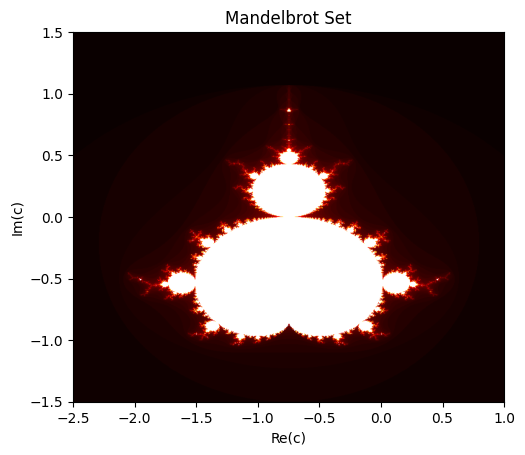

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def mandelbrot(c, max_iter):
    z = 0
    for i in range(max_iter):
        z = z*z + c
        if abs(z) > 2:
            return i
    return max_iter

def plot_mandelbrot(x_min, x_max, y_min, y_max, width, height, max_iter):
    x = np.linspace(x_min, x_max, width)
    y = np.linspace(y_min, y_max, height)
    X, Y = np.meshgrid(x, y)
    Z = X + 1j * Y
    img = np.zeros((height, width))

    for i in range(height):
        for j in range(width):
            c = Z[i, j]
            img[i, j] = mandelbrot(c, max_iter)

    plt.imshow(img.T, cmap='hot', extent=[x_min, x_max, y_min, y_max])
    plt.xlabel('Re(c)')
    plt.ylabel('Im(c)')
    plt.title('Mandelbrot Set')
    plt.show()

# Define the parameters for the plot
x_min = -2.5 #0.32
x_max = 1 #0.36
y_min = -1.5 #-0.54
y_max = 1.5 #-0.50
width = 800
height = 600
max_iter = 100

# Call the plotting function
plot_mandelbrot(x_min, x_max, y_min, y_max, width, height, max_iter)


# Projectile motion

Range on flat ground<p>
range = $\frac{v^2*sin(2\theta)}g$

In [ ]:
import math

# initial velocity in meters per second
v = 50

# initial angle of projectile in radians
a = math.pi/4

# gravity in meters per second squared
g = 9.8

range = (v**2*math.sin(2*a))/g
print(round(range,3), "meters")


Range on a slope inclining at angle b from the horizontal<p>
range = $\frac{v^2*[sin(2\theta-b)-sin(b)]}{g*cos^2(b)}$

In [ ]:
import math

# initial velocity in meters per second
v = 50

# initial angle of projectile in radians
a = math.pi/4

# angle the slope makes with the horizontal in radians
b = math.pi/4.1

# gravity in meters per second squared
g = 9.8

range = (v**2*(math.sin(2*a-b)-math.sin(b)))/(g*math.cos(b)**2)
print(round(range,3), "meters")


Range on a slope declining at angle d from the horizontal<p>
range = $\frac{2*v^2*sin(\theta)*cos(\theta-d)}{g*cos^2(d)}$

In [ ]:
import math

# initial velocity in meters per second
v = 50

# initial angle projectile makes with plane in radians
a = math.pi/4

# angle the plane makes with the horizontal in radians
d = math.pi/6

# gravity in meters per second squared
g = 9.8

range = (2*v**2*math.sin(a)*math.cos(a-d))/(g*math.cos(d)**2)
print(round(range,3), "meters")


Maximum height of a projectile<p>
height = $\frac{v^2*sin^2(\theta)}{2g}$

In [ ]:
import math

# initial velocity in meters per second
v = 50

# initial angle of projectile in radians
a = math.pi/4

# gravity in meters per second squared
g = 9.8

height = (v**2*math.sin(a)**2)/(2*g)
print(round(height,3), "meters")


# Hours of daylight
<p>
source:
 https://web.archive.org/web/20180128172128/http://mathforum.org/library/drmath/view/56478.html



In [ ]:
import math

# latitude in degrees (up to 65)
L = 65

# day of the year
J = 173

# calculations in several steps
t1 = 0.9671396*math.tan(0.00860*(J-186))
p = math.asin(0.39795*math.cos(0.2163108 + 2*math.atan(t1)))
d1 = math.sin(0.8333*math.pi/180) + math.sin(L*math.pi/180) * math.sin(p)
d2 = math.cos(L*math.pi/180)*math.cos(p)
daylight = 24 - (24/math.pi)*math.acos(d1/d2)
print(round(daylight,1), " hours")


22.1  hours


# Logistic growth

y = $\frac{c}{1+ae^{-bx}}$<p>

Horizontal asymptotes at y = c and y = 0


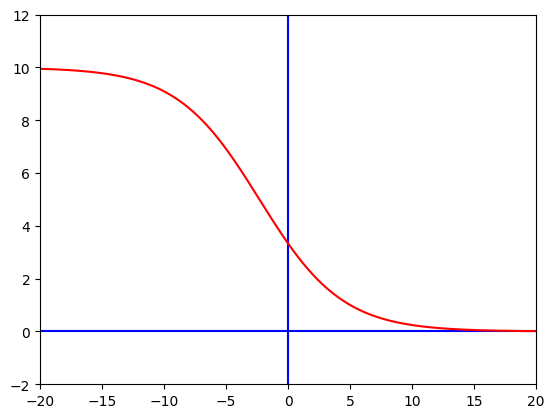

In [ ]:
from ast import Break
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

# carrying capacity (maximum y value)
c = 10

# a > 0
a = 2

# growth if b > 0, decay if b < 0
b = -0.3

# find good xmin and xmax values
for x_test in range(1000):
    y = c/(1+a*math.e**(-b*x_test))
    if b>0 and y>(c/2):
        xmax = int(round(5*x_test))
        xmin = -xmax
        break

    if b<0 and y<(c/2):
        xmax = int(round(5*x_test))
        xmin = -xmax
        break


if abs(xmax-xmin)<20:
    xmin = -20
    xmax = 20

# Graph dimensions
# xmin = calculated
# xmax = calculated
ymin = -2
ymax = c + 2
points = 10*(xmax-xmin)
x = np.linspace(xmin, xmax, points)

fig, ax = plt.subplots()
plt.axis([xmin,xmax, ymin,ymax])
plt.plot([xmin, xmax],[0,0],'b')
plt.plot([0,0],[ymin, ymax],'b')

y = c/(1+a*math.e**(-b*x))
plt.plot(x,y,'r')

plt.show()

# Limits

In [ ]:
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import math

# Graph dimensions
xmin = -7
xmax = 7
ymin = -2
ymax = 2
points = 10*(xmax-xmin)
x = np.linspace(xmin, xmax, points)

fig, ax = plt.subplots()
plt.axis([xmin,xmax, ymin,ymax])
plt.plot([xmin, xmax],[0,0],'b')
plt.plot([0,0],[ymin, ymax],'b')

y = np.sin(x)/x
plt.plot(x,y,'r')

plt.show()

# testing y values
x_value = 0
diff = 0.01
x_test_right = x_value + diff
x_test_left = x_value - diff

print(math.sin(x_test_right)/x_test_right)
print(math.sin(x_test_left)/x_test_left)



Trig factoring

In [ ]:
from sympy import *

x,y = symbols('x y')
init_printing(use_unicode=True)

# trigsimp(sin(x)**2 + cos(x)**2)
# trigsimp(1 + cot(x)**2)
# trigsimp(1/sec(x))
# trigsimp(1/cos(x)) no

# trigsimp(sin(x+y)) no
# trigsimp(sin(x)*cos(y)+cos(x)*sin(y))
trigsimp(sin(x)/cos(x))
# trigsimp(tan(x)) no

# no half angle formulas
# trigsimp((1-cos(x))/sin(x)) no
# trigsimp(tan(x/2)) no

# yes double angle formulas
# trigsimp(sin(2*x)) no
# trigsimp(2*sin(x)*cos(x))
# trigsimp((2*tan(x))/(1-tan(x)**2))

# trigsimp(0.5*(cos(x-y) - cos(x+y)))
# trigsimp(sin(x)+sin(y)) no
trigsimp(2*sin((x+y)/2)*cos((x-y)/2))


sin(x) + sin(y)

.

.

# Poisson Distribution

y = $\frac{\lambda^x}{x!}*e^{-\lambda}$<p>
where lambda ($\lambda$) is the expected value<p>
What is the probability that x happens?

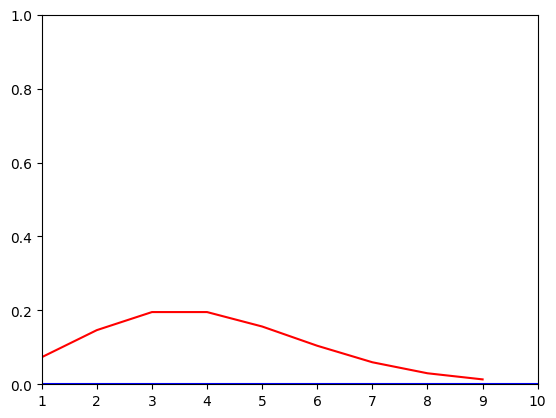

In [ ]:
import math
import matplotlib.pyplot as plt
from IPython import display
import numpy as np

# expected value
lam = 4

# Graph dimensions
xmin = 1
xmax = 10 # could change
ymin = 0
ymax = 1

# create arrays to plot
x = []
y = []

for x_next in range(1,10):
    x.append(x_next)
    y.append((lam**x_next)/math.factorial(x_next)*math.e**(-lam))

fig, ax = plt.subplots()
plt.axis([xmin,xmax, ymin,ymax])
plt.plot([xmin, xmax],[0,0],'b')
plt.plot([0,0],[ymin, ymax],'b')

plt.plot(x,y,'r')

plt.show()
